# 이상탐지 실습하기


- EllipticEnvelope


- LocalOutlierFactor


- IsolationForest

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn 이상탐지 알고리즘
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

## 데이터 생성

In [3]:
# 랜덤 시드 고정 (실습 결과 재현 가능하게)
rng = np.random.RandomState(42)

# 정상 데이터 생성
# 평균 근처에 밀집된 데이터
X_train = 0.2 * rng.randn(1000, 2)

# 두 개의 클러스터 만들기
X_train = np.r_[X_train + 3, X_train]

# pandas 데이터프레임 변환
X_train = pd.DataFrame(X_train, columns=['x1', 'x2'])


# 테스트용 정상 데이터
X_test = 0.2 * rng.randn(200, 2)
X_test = np.r_[X_test + 3, X_test]
X_test = pd.DataFrame(X_test, columns=['x1', 'x2'])


# 이상치 데이터 생성
# 정상 데이터 범위 밖에서 랜덤 생성
outliers = rng.uniform(low=-5, high=5, size=(50, 2))
outliers = pd.DataFrame(outliers, columns=['x1', 'x2'])


## EllipticEnvelope

In [4]:
# contamination
# 데이터 중 이상치 비율을 의미
clf1 = EllipticEnvelope(contamination=0.1, random_state=42)

# 모델 학습
clf1.fit(X_train)

# 예측
pred_train1 = clf1.predict(X_train)
pred_outliers1 = clf1.predict(outliers)



## Local Outlier Factor

In [ ]:
# n_neighbors
# 주변 이웃 개수
clf2 = LocalOutlierFactor(
    n_neighbors=20,
    novelty=True,      # 새로운 데이터 예측 가능
    contamination=0.1   #  데이터 중 10%를 이상치라고 가정
)

# 학습
clf2.fit(X_train)

# 예측
pred_outliers2 = clf2.predict(outliers)



c:\AI\envs\ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


## Isolation Forest

In [6]:
clf3 = IsolationForest(
    contamination=0.1,
    random_state=42
)

# 학습
clf3.fit(X_train)

# 예측
pred_outliers3 = clf3.predict(outliers)


## 결과

- EllipticEnvelope : 분포 기반 (타원,타원밖 = 이상치)


- LOF : 밀도(이웃,군집) 기반


- IsolationForest : 트리 기반(랜덤 트리)

In [ ]:
# 발견한 이상치 결과
print("EllipticEnvelope detected:", (pred_outliers1 == -1).sum())
print("LOF detected:", (pred_outliers2 == -1).sum())
print("IsolationForest detected:", (pred_outliers3 == -1).sum())

EllipticEnvelope detected: 44
LOF detected: 49
IsolationForest detected: 49


LOF / IsolationForest 가 이상치를 더 많이 탐지 .


같은 데이터에서도 알고리즘의 방식에 따라 탐지되는 이상치의 개수가 달라질 수 있다.


## 시각화

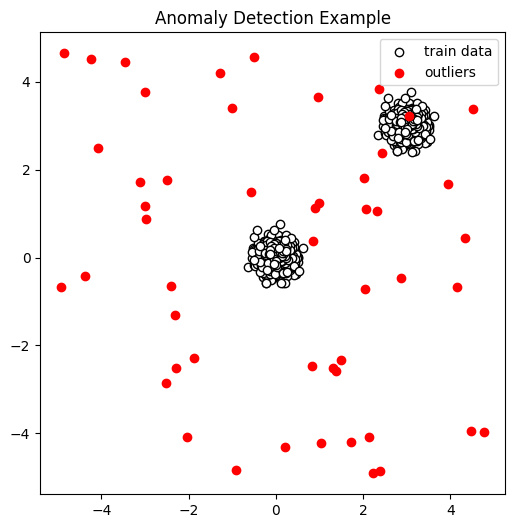

In [7]:
plt.figure(figsize=(6,6))

# 정상 데이터
plt.scatter(
    X_train.x1,
    X_train.x2,
    c='white',
    edgecolor='k',
    label="train data"
)

# 이상치 데이터
plt.scatter(
    outliers.x1,
    outliers.x2,
    c='red',
    label="outliers"
)

plt.legend()
plt.title("Anomaly Detection Example")
plt.show()